## DESCRIPTION OF THE DATASET : 

Here, we have came at the conclusion that how many people had survived and how many people had died at what age groups. And also we predicted that most of the people died on the way to 'S' place means 'Southampton'. And many more.

In [1]:
#Importing basic Python libraries : 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
#To load the dataset
titanic = pd.read_csv("titanic.csv")
titanic.sample(10)    #to show random 10 records

#Here, target outcome is the 'Survived column'

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
509,510,1,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
513,514,1,1,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)",female,54.0,1,0,PC 17603,59.4000,NaN,C
383,384,1,1,"Holverson, Mrs. Alexander Oskar (Mary Aline To...",female,35.0,1,0,113789,52.0000,NaN,S
538,539,0,3,"Risien, Mr. Samuel Beard",male,NaN,0,0,364498,14.5000,NaN,S
563,564,0,3,"Simmons, Mr. John",male,NaN,0,0,SOTON/OQ 392082,8.0500,NaN,S
453,454,1,1,"Goldenberg, Mr. Samuel L",male,49.0,1,0,17453,89.1042,C92,C
811,812,0,3,"Lester, Mr. James",male,39.0,0,0,A/4 48871,24.1500,NaN,S
845,846,0,3,"Abbing, Mr. Anthony",male,42.0,0,0,C.A. 5547,7.5500,NaN,S
128,129,1,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Remove unwanted columns such as PassengerId, Name, Ticket
titanic.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)

In [4]:
#To show all information of given dataset
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [5]:
#Show the description of the dataset
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#Check no. of records (rows and columns)
titanic.shape

(891, 9)

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


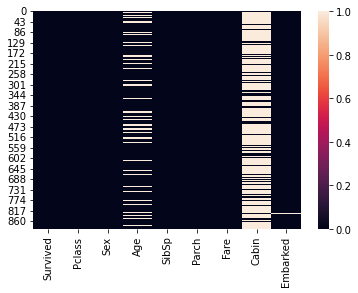

In [7]:
#Check null values
print(titanic.isnull().sum())

#Visualise
sns.heatmap(titanic.isnull())
plt.show()

In [8]:
#Check datatypes
titanic.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked     object
dtype: object

In [9]:
#Find the percentage of null values
titanic.isnull().sum() * 100 / titanic.shape[0]

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

In [10]:
#As the cabin column have more than 60% null values, so it must be removed
titanic.drop("Cabin", axis = 1, inplace = True)

In [11]:
#To fill the null values of Age column
titanic['Age'].fillna(titanic['Age'].mean(), inplace = True)

S    644
C    168
Q     77
Name: Embarked, dtype: int64


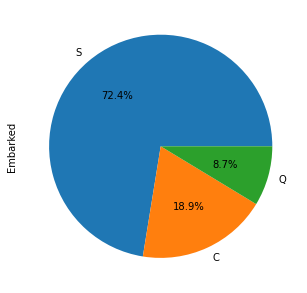

In [12]:
#Finding the most appeared values in Embarked column
plt.figure(figsize = (5, 7))    #to increase the size of the page
print(titanic['Embarked'].value_counts())
titanic['Embarked'].value_counts().plot(kind = 'pie', autopct = '%.1f%%')  #1 means only 1 digit after decimal
plt.show()

#Here, S is Southampton, C is Cherbourg, Q is Queenstown.

In [13]:
#To fill the null values of Embarked column with "S" because mostly people are going to 'S' place
titanic['Embarked'].fillna('S', inplace = True)

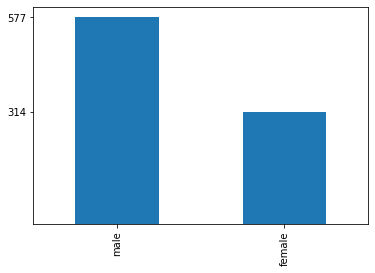

In [14]:
#How many total Males & Females were there
f = titanic['Sex'].value_counts()
titanic['Sex'].value_counts().plot(kind = 'bar')
plt.yticks(f)
plt.show()

In [15]:
#To show the records of females & males passengers of 1st, 2nd & 3rd class in Pclass
print("Number of Females in Pclass '1' : ", titanic[(titanic['Pclass'] == 1) & (titanic['Sex'] == 'female')].shape[0])
print("Number of Females in Pclass '2' : ", titanic[(titanic['Pclass'] == 2) & (titanic['Sex'] == 'female')].shape[0])
print("Number of Females in Pclass '3' : ", titanic[(titanic['Pclass'] == 3) & (titanic['Sex'] == 'female')].shape[0])
print('\n')
print("Number of Males in Pclass '1' : ", titanic[(titanic['Pclass'] == 1) & (titanic['Sex'] == 'male')].shape[0])
print("Number of Males in Pclass '2' : ", titanic[(titanic['Pclass'] == 2) & (titanic['Sex'] == 'male')].shape[0])
print("Number of Males in Pclass '3' : ", titanic[(titanic['Pclass'] == 3) & (titanic['Sex'] == 'male')].shape[0])

Number of Females in Pclass '1' :  94
Number of Females in Pclass '2' :  76
Number of Females in Pclass '3' :  144


Number of Males in Pclass '1' :  122
Number of Males in Pclass '2' :  108
Number of Males in Pclass '3' :  347


In [16]:
#To show the total Fare according to Pclass
titanic.groupby('Pclass')['Fare'].sum()

Pclass
1    18177.4125
2     3801.8417
3     6714.6951
Name: Fare, dtype: float64

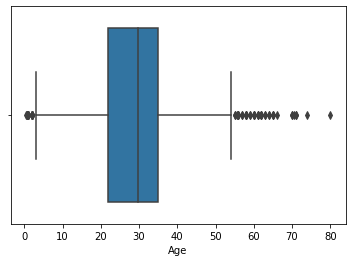

People with age in between 60 to 80 are :  26
People with age below 10 are :  64


In [17]:
#To show the difference between ages gap
sns.boxplot((titanic['Age']))
plt.show()
print("People with age in between 60 to 80 are : ", titanic[(titanic['Age'] >= 60) & (titanic['Age'] <= 80)].shape[0])
        #26 old age people
print("People with age below 10 are : ", titanic[(titanic['Age'] <= 10)].shape[0])
        #64 children were there

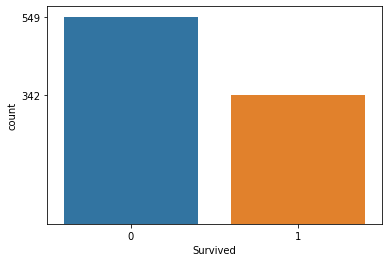

Out of 891, '62%' People died in the accident.


In [18]:
#To check data is balanced or unbalanced and how many people were died 
f = titanic['Survived'].value_counts()
sns.countplot(data = titanic, x = 'Survived')
plt.yticks(f)
plt.show()
death_rate = round((titanic['Survived'].value_counts().values[0] / titanic.shape[0]) * 100)
print("Out of 891, '{}%' People died in the accident.".format(death_rate))

#Data is balanced

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


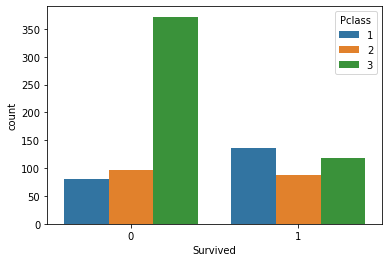

In [19]:
#To show how many people Survived according to Passenger Class
print(pd.crosstab(titanic['Pclass'], titanic['Survived']))
sns.countplot(titanic['Survived'], hue = titanic['Pclass'])
plt.show()

#0 means not survived, & 1 means survived. And it shows that most of the people died who were in 3rd class

Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  219


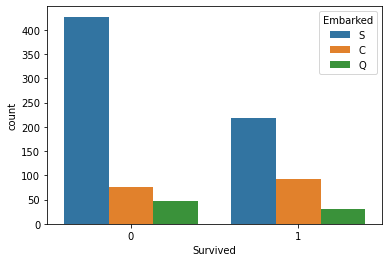

In [20]:
#To show how many people Survived according to Embarked
print(pd.crosstab(titanic['Embarked'], titanic['Survived']))
sns.countplot(titanic['Survived'], hue = titanic['Embarked'])
plt.show()

#Most of the people survived who were going to C (Cherbourg) place, 
#but most of the people died who were going to S (Southampton) place.

In [21]:
#Handling categorical and numerical type data
titanic_cat = titanic.select_dtypes('object')   #categorical type
titanic_num = titanic.select_dtypes(['int64', 'float64'])   #numerical type

In [22]:
#To convert object type data into numerical type data using LabelEncoder
from sklearn.preprocessing import LabelEncoder

for col in titanic_cat : 
    #Create object of LabelEncoder class
    le = LabelEncoder()
    titanic_cat[col] = le.fit_transform(titanic_cat[col])

In [23]:
#To concatenate titanic_cat and titanic_num
titanic_new = pd.concat([titanic_cat, titanic_num], axis = 1)
titanic_new.head()

,Sex,Embarked,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,2,0,3,22.0,1,0,7.2500
1,0,0,1,1,38.0,1,0,71.2833
2,0,2,1,3,26.0,0,0,7.9250
3,0,2,1,1,35.0,1,0,53.1000
4,1,2,0,3,35.0,0,0,8.0500


In [24]:
#Select Input (features) and Output (target)
X = titanic_new.drop('Survived', axis = 1)
Y = titanic_new['Survived']

In [25]:
#Split the model into 70% Training data and 30% Testing data
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1)

In [26]:
#Apply Standard Scaling on 70% input Training data and 30% input Testing data
from sklearn.preprocessing import StandardScaler

#Create object of StandardScaler class
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

#NOTE : fit_transform only uses in 70% input training data (fit means to train and then change)
#       transform only uses in 30% testing data

In [27]:
#Create a user defined function
def create_model(model) : 
    model.fit(X_train, Y_train)         #Train the model with 70% data
    Y_pred = model.predict(X_test)      #Test the model with 70% data
    print(classification_report(Y_test, Y_pred))
    print(confusion_matrix(Y_test, Y_pred))
    return model

In [28]:
#Call Evaluation score 
from sklearn.metrics import classification_report, confusion_matrix

In [29]:
#Use baseline model : use LogisticRegression class
from sklearn.linear_model import LogisticRegression 

#Create object of LogisticRegression class
lr = LogisticRegression()

In [30]:
#Call function 
lr = create_model(lr)

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       153
           1       0.76      0.68      0.72       115

    accuracy                           0.77       268
   macro avg       0.77      0.76      0.76       268
weighted avg       0.77      0.77      0.77       268

[[129  24]
 [ 37  78]]


In [31]:
#Perform Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

#Create object of DecisionTreeClassifier class
dt = DecisionTreeClassifier(random_state = 1)
#by default Gini Index

In [32]:
#Call function
dt = create_model(dt)

#Reason behind less score : the model is overfit

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       153
           1       0.76      0.63      0.69       115

    accuracy                           0.76       268
   macro avg       0.76      0.74      0.75       268
weighted avg       0.76      0.76      0.75       268

[[130  23]
 [ 42  73]]


In [33]:
#Sorting values
IG = dt.feature_importances_
cols = X.columns

#Create a dictionary
dic = {'Input_X' : cols, 'Information_Gain' : IG}
df = pd.DataFrame(dic)
df.sort_values("Information_Gain", ascending = False)

,Input_X,Information_Gain
0,Sex,0.330279
3,Age,0.244226
6,Fare,0.211783
2,Pclass,0.116226
4,SibSp,0.064300
1,Embarked,0.028432
5,Parch,0.004754


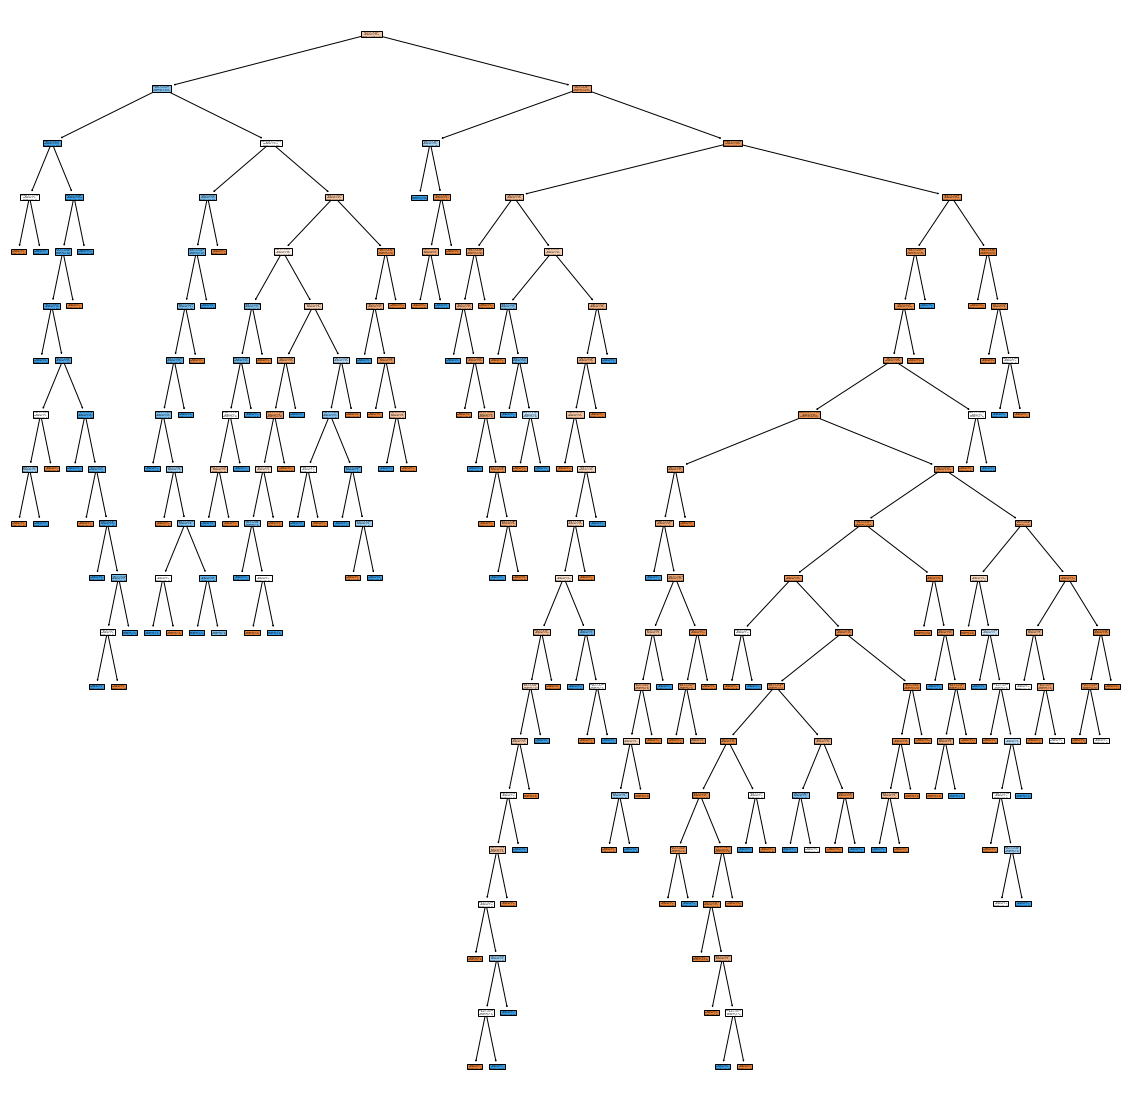

In [34]:
#Create a Tree
from sklearn import tree
plt.figure(figsize = (20, 20))
features = X.columns
_ = tree.plot_tree(dt, feature_names = features, filled = True)

In [35]:
#To reduce the output situation, use Pruning Technique
#formula : 1 - P(yes)^2 - Q(no)^2
#max_depth : inbuilt parameter
#Create object for max_depth
dt1 = DecisionTreeClassifier(max_depth = 1, random_state = 1)   #max_depth should be less than 8

In [36]:
#Call function
dt1 = create_model(dt1)

              precision    recall  f1-score   support

           0       0.75      0.84      0.80       153
           1       0.75      0.63      0.69       115

    accuracy                           0.75       268
   macro avg       0.75      0.74      0.74       268
weighted avg       0.75      0.75      0.75       268

[[129  24]
 [ 42  73]]


In [37]:
#Sorting values
IG = dt1.feature_importances_

#Create a dictionary
dic = {"Input_X" : cols, "Information_Gain" : IG}
df1 = pd.DataFrame(dic)
df1.sort_values("Information_Gain", ascending = False)

,Input_X,Information_Gain
0,Sex,1.0
1,Embarked,0.0
2,Pclass,0.0
3,Age,0.0
4,SibSp,0.0
5,Parch,0.0
6,Fare,0.0


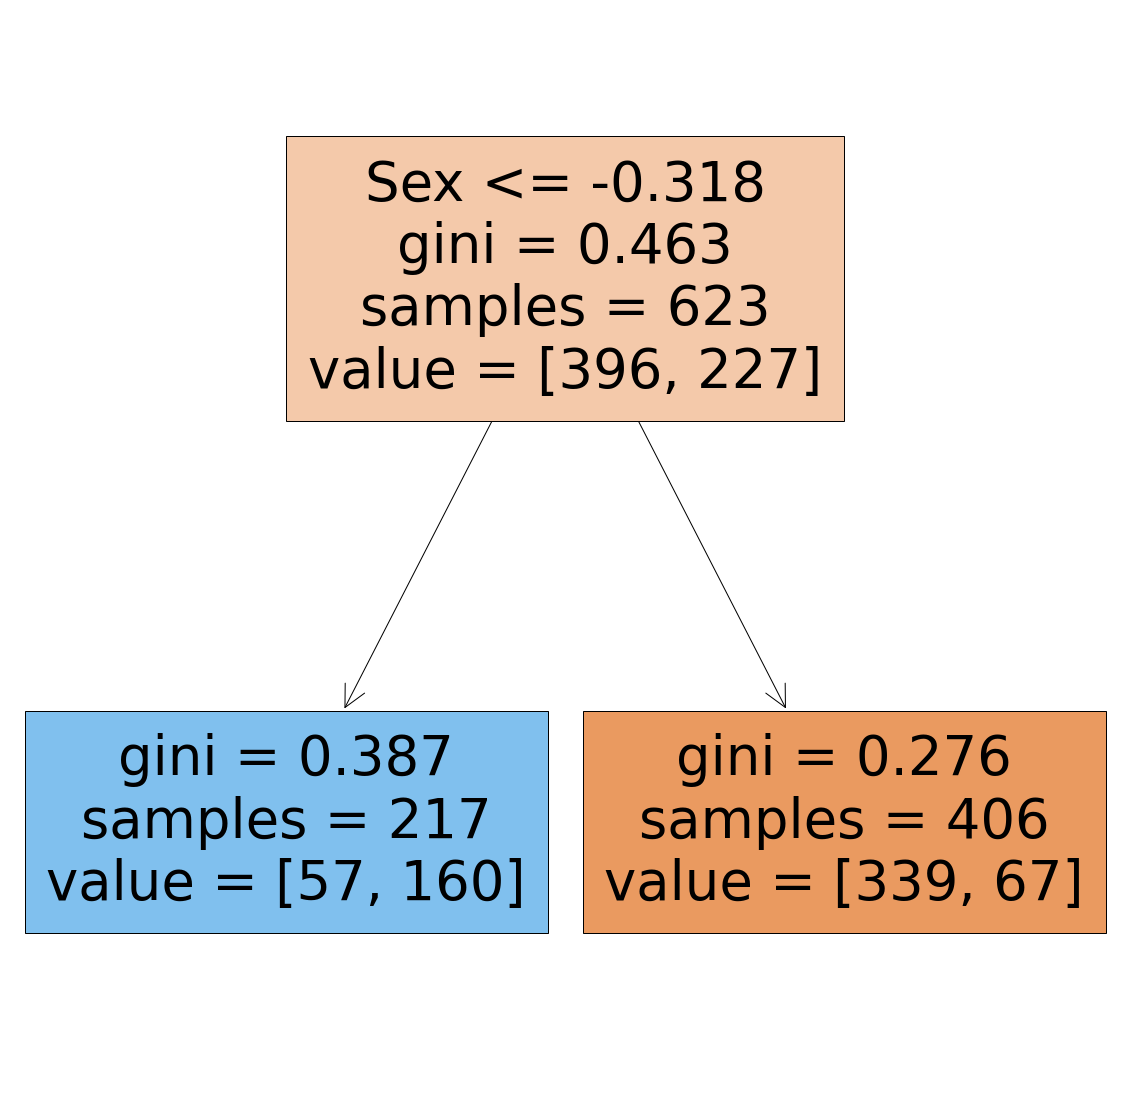

In [38]:
#Create a tree
plt.figure(figsize = (20,20))
_ = tree.plot_tree(dt1, feature_names = features, filled = True)

In [39]:
#Pruning technique of min_samples_leaf : inbuilt parameter
#Create object for min_samples_leaf
dt2 = DecisionTreeClassifier(min_samples_leaf = 50, random_state = 1)

In [40]:
#Call function 
dt2 = create_model(dt2)

              precision    recall  f1-score   support

           0       0.70      0.98      0.82       153
           1       0.94      0.43      0.60       115

    accuracy                           0.75       268
   macro avg       0.82      0.71      0.71       268
weighted avg       0.80      0.75      0.72       268

[[150   3]
 [ 65  50]]


In [41]:
#Sorting values
IG = dt2.feature_importances_

#Create a dictionary
dic = {"Input_X" : cols, "Information_Gain" : IG}
df2 = pd.DataFrame(dic)
df2.sort_values("Information_Gain", ascending = False)

,Input_X,Information_Gain
0,Sex,0.727225
2,Pclass,0.178130
3,Age,0.048417
6,Fare,0.046227
1,Embarked,0.000000
4,SibSp,0.000000
5,Parch,0.000000


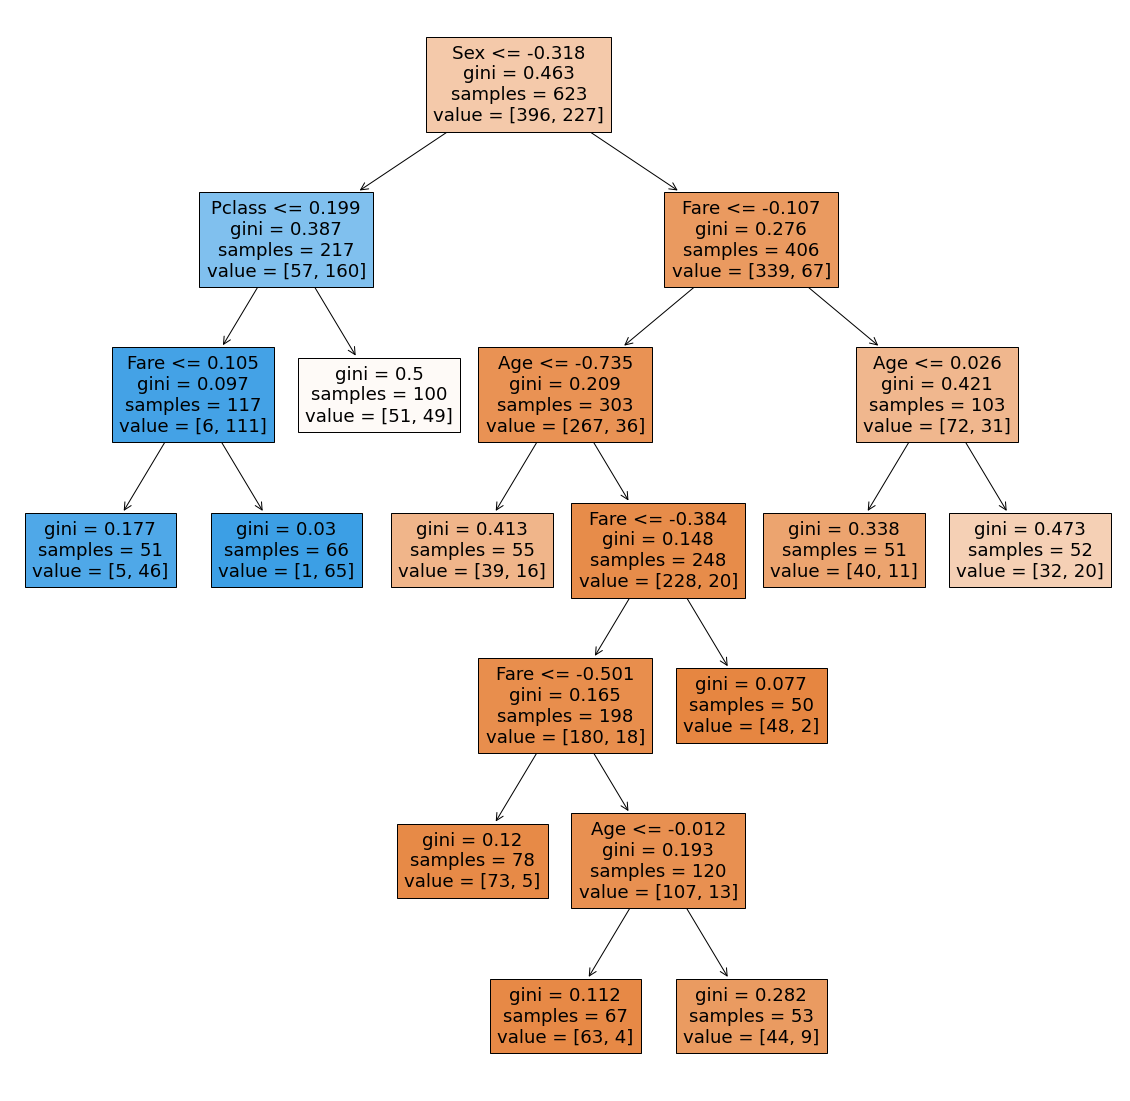

In [42]:
#Create a tree
plt.figure(figsize = (20,20))
_ = tree.plot_tree(dt2, feature_names = features, filled = True)

In [43]:
#CONCLUSION : 
#In this model, Pruning Technique of max_depth is best

In [44]:
#Use entropy method of Decision Tree for max_depth
#formula : -P(yes) * log2(P(yes)) - Q(no) * log2(Q(no))
#here, log2 means base of log = 2
#Create object for max_depth
dt3 = DecisionTreeClassifier(criterion = 'entropy', max_depth = 1, random_state = 1)

In [45]:
#Call function
dt3 = create_model(dt3)

              precision    recall  f1-score   support

           0       0.75      0.84      0.80       153
           1       0.75      0.63      0.69       115

    accuracy                           0.75       268
   macro avg       0.75      0.74      0.74       268
weighted avg       0.75      0.75      0.75       268

[[129  24]
 [ 42  73]]


In [46]:
#Use entropy method of Decision Tree for min_samples_leaf
#Create object of min_samples_leaf
dt4 = DecisionTreeClassifier(criterion = 'entropy', min_samples_leaf = 60, random_state = 1)

In [47]:
#Call function 
dt4 = create_model(dt4)

              precision    recall  f1-score   support

           0       0.70      0.98      0.82       153
           1       0.94      0.43      0.60       115

    accuracy                           0.75       268
   macro avg       0.82      0.71      0.71       268
weighted avg       0.80      0.75      0.72       268

[[150   3]
 [ 65  50]]


In [48]:
#CONCLUSION : 
#In this model, Entropy Technique of max_depth is best

In [49]:
#Apply Random Forest Tree of Boostraping Method 
from sklearn.ensemble import RandomForestClassifier

#Create object of RandomForestClassifier class
rfc = RandomForestClassifier(n_estimators = 10, max_features = 1, random_state = 1)
#n_estimators means no. of decision trees we take 
#here, max_fetures means how many inputs we take

In [50]:
#Call function
rfc = create_model(rfc)

              precision    recall  f1-score   support

           0       0.75      0.86      0.80       153
           1       0.77      0.63      0.69       115

    accuracy                           0.76       268
   macro avg       0.76      0.74      0.75       268
weighted avg       0.76      0.76      0.76       268

[[132  21]
 [ 43  72]]


In [51]:
#CONCLUSION : 
#In this model, DecisionTree is best

In [52]:
#Apply Ada Boost of Boosting Technique
from sklearn.ensemble import AdaBoostClassifier

#Create object of AdaBoostClassifier class
ada = AdaBoostClassifier(n_estimators = 80, random_state = 1)
#n_estimators must be less than 100

In [53]:
#Call function
ada = create_model(ada)

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       153
           1       0.79      0.68      0.73       115

    accuracy                           0.78       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268

[[132  21]
 [ 37  78]]


In [54]:
#Apply Gradient Boosting of Boosting Technique
from sklearn.ensemble import GradientBoostingClassifier

#Create a object of GradientBoostingClassifier class
gbc = GradientBoostingClassifier(n_estimators = 90, random_state = 1)

In [55]:
#Call function 
gbc = create_model(gbc)

              precision    recall  f1-score   support

           0       0.75      0.90      0.82       153
           1       0.82      0.60      0.69       115

    accuracy                           0.77       268
   macro avg       0.79      0.75      0.76       268
weighted avg       0.78      0.77      0.77       268

[[138  15]
 [ 46  69]]


In [56]:
#CONCLUSION : 
#In this model, Boosting Technique of Ada Boost technique is best

In [57]:
#Apply Extreme Gradient Boosting (XGB) of Boosting Technique
from xgboost import XGBClassifier

#Create object of XGBClassifier
xgb = XGBClassifier(n_estimators = 90, reg_alpha = 1, random_state = 1)
#automatic overfitting : reg means regularization and alpha means lambda : hyperparameter and 1 means True
#n_estimators can be <= 100

In [58]:
#Call function
xgb = create_model(xgb)

[17:17:49] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
              precision    recall  f1-score   support

           0       0.74      0.90      0.81       153
           1       0.82      0.58      0.68       115

    accuracy                           0.76       268
   macro avg       0.78      0.74      0.75       268
weighted avg       0.77      0.76      0.76       268

[[138  15]
 [ 48  67]]


In [59]:
#Apply KNN algorithm
from sklearn.neighbors import KNeighborsClassifier

#Create object of KNeighborsClassifier class
knn = KNeighborsClassifier(n_neighbors = 3, metric = 'minkowski', p = 2)

#'K' is the hyperparameter for KNN and it means it selects the distance between 2  points 
#n_neighbors : To define the required neighbors of the algo. 
#metric = 'minkowski' : This is the default parameter and it decides the distance between the data points
#p = 2 : It is the equivalent to the standard Euclidean metric means sqrt(X2 - X1) ** 2 + (Y2 - Y1) ** 2

In [60]:
#Call function
knn = create_model(knn)

              precision    recall  f1-score   support

           0       0.76      0.86      0.80       153
           1       0.77      0.63      0.70       115

    accuracy                           0.76       268
   macro avg       0.76      0.75      0.75       268
weighted avg       0.76      0.76      0.76       268

[[131  22]
 [ 42  73]]


In [61]:
#Apply Linear kernel function of SVM (Support Vector Machine)
from sklearn.svm import LinearSVC

#Create object for LinearSVC class (hard margin)
svc = LinearSVC(random_state = 1)
#by default hard margin means we did not added error

In [62]:
#Call function
svc = create_model(svc)

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       153
           1       0.76      0.66      0.71       115

    accuracy                           0.76       268
   macro avg       0.76      0.75      0.76       268
weighted avg       0.76      0.76      0.76       268

[[129  24]
 [ 39  76]]


In [63]:
#Reduce overfitting situation (soft margin) means added some error on Training time
#Create object of LinearSVC class
svc1 = LinearSVC(random_state = 1, C = 0.5)

In [64]:
#Call function
svc1 = create_model(svc1)

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       153
           1       0.76      0.66      0.71       115

    accuracy                           0.76       268
   macro avg       0.76      0.75      0.76       268
weighted avg       0.76      0.76      0.76       268

[[129  24]
 [ 39  76]]


In [65]:
#Apply Non-Linear kernel SVC
#Polynomial kernel function (non-linear)
#increase the low dimension to high dimension
from sklearn.svm import SVC

#Create object polynomial class
poly = SVC(random_state = 1, kernel = 'poly')

In [66]:
#Call function
poly = create_model(poly)

              precision    recall  f1-score   support

           0       0.75      0.92      0.83       153
           1       0.84      0.60      0.70       115

    accuracy                           0.78       268
   macro avg       0.80      0.76      0.76       268
weighted avg       0.79      0.78      0.77       268

[[140  13]
 [ 46  69]]


In [67]:
#Here, the score of Polynomial is not so good, use radial basis of kernel function
#Apply radial basis kernel function (non-linear)
radial = SVC(random_state = 1, kernel = 'rbf')

In [68]:
#Call function
radial = create_model(radial)

              precision    recall  f1-score   support

           0       0.74      0.92      0.82       153
           1       0.85      0.57      0.68       115

    accuracy                           0.77       268
   macro avg       0.79      0.75      0.75       268
weighted avg       0.79      0.77      0.76       268

[[141  12]
 [ 49  66]]


#### CONCLUSION : 

In this dataset, the accuracy of Pruning Techinque (max_depth) of Decision Tree, Ada Boosting & SVM (Linear) is nice.